In [23]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pybbn.graph.dag import Bbn
from pybbn.graph.dag import Edge, EdgeType
from pybbn.graph.jointree import EvidenceBuilder
from pybbn.graph.node import BbnNode
from pybbn.graph.variable import Variable
from pybbn.pptc.inferencecontroller import InferenceController

In [24]:
# Display up to 50 columns in pandas DataFrame
pd.options.display.max_columns = 50

In [25]:
# Load the CSV file
df = pd.read_csv('weatherAUS.csv', encoding='utf-8')

In [26]:
# Filter out rows with null values in the 'RainTomorrow' column
df = df[pd.isnull(df['RainTomorrow']) == False]

In [27]:
# Fill NaN values only for numeric columns
df = df.fillna(df.mean(numeric_only=True))

In [28]:
# Apply categorical transformations
df['WindGustSpeedCat'] = df['WindGustSpeed'].apply(lambda x: '0.<=40' if x <= 40 else '1.40-50' if 40 < x <= 50 else '2.>50')
df['Humidity9amCat'] = df['Humidity9am'].apply(lambda x: '1.>60' if x > 60 else '0.<=60')
df['Humidity3pmCat'] = df['Humidity3pm'].apply(lambda x: '1.>60' if x > 60 else '0.<=60')

In [29]:
# Print the DataFrame to check if transformations are correct
print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  01-12-2008   Albury     13.4     22.9       0.6     5.469824  7.624853   
1  02-12-2008   Albury      7.4     25.1       0.0     5.469824  7.624853   
2  03-12-2008   Albury     12.9     25.7       0.0     5.469824  7.624853   
3  04-12-2008   Albury      9.2     28.0       0.0     5.469824  7.624853   
4  05-12-2008   Albury     17.5     32.3       1.0     5.469824  7.624853   

  WindGustDir  WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  \
0           W           44.0          W        WNW          20.0   
1         WNW           44.0        NNW        WSW           4.0   
2         WSW           46.0          W        WSW          19.0   
3          NE           24.0         SE          E          11.0   
4           W           41.0        ENE         NW           7.0   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  \
0          24.0         71.0         22.0      

In [30]:
# Function to calculate probabilities
def probs(data, child, parent1=None, parent2=None):
    if parent1 is None:
        # Calculate probabilities for a node without parents
        prob = pd.crosstab(data[child], 'Empty', margins=False, normalize='columns').sort_index().to_numpy().reshape(-1).tolist()
    else:
        # Check if the child node has 1 parent or 2 parents
        if parent2 is None:
            # Calculate probabilities for a node with 1 parent
            prob = pd.crosstab(data[parent1], data[child], margins=False, normalize='index').sort_index().to_numpy().reshape(-1).tolist()
        else:
            # Calculate probabilities for a node with 2 parents
            prob = pd.crosstab([data[parent1], data[parent2]], data[child], margins=False, normalize='index').sort_index().to_numpy().reshape(-1).tolist()
    return prob


In [31]:
# Define nodes with variables and probabilities
H9am = BbnNode(Variable(0, 'H9am', ['<=60', '>60']), probs(df, child='Humidity9amCat'))
H3pm = BbnNode(Variable(1, 'H3pm', ['<=60', '>60']), probs(df, child='Humidity3pmCat', parent1='Humidity9amCat'))
W = BbnNode(Variable(2, 'W', ['<=40', '40-50', '>50']), probs(df, child='WindGustSpeedCat'))
RT = BbnNode(Variable(3, 'RT', ['No', 'Yes']), probs(df, child='RainTomorrow', parent1='Humidity3pmCat', parent2='WindGustSpeedCat'))


In [32]:
# Create the Bayesian Belief Network
bbn = Bbn() \
    .add_node(H9am) \
    .add_node(H3pm) \
    .add_node(W) \
    .add_node(RT) \
    .add_edge(Edge(H9am, H3pm, EdgeType.DIRECTED)) \
    .add_edge(Edge(H3pm, RT, EdgeType.DIRECTED)) \
    .add_edge(Edge(W, RT, EdgeType.DIRECTED))


In [33]:
# Apply inference
join_tree = InferenceController.apply(bbn)

# Set positions for nodes in the graph
pos = {0: (-1, 2), 1: (-1, 0.5), 2: (1, 0.5), 3: (0, -1)}


In [34]:
# Define graph drawing options
options = {
    "font_size": 16,
    "node_size": 4000,
    "node_color": "white",
    "edgecolors": "black",
    "edge_color": "red",
    "linewidths": 5,
    "width": 5,
}

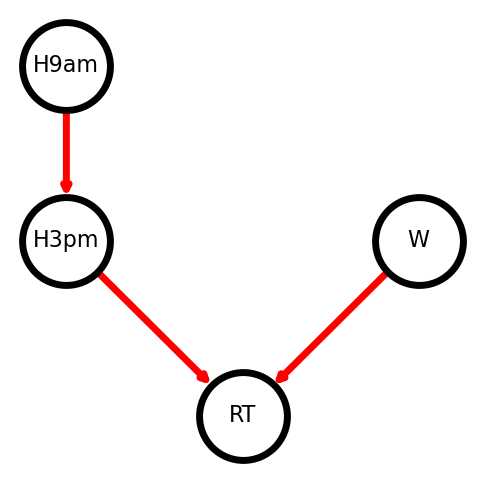

In [20]:
# Convert the BBN to a NetworkX graph and draw it
n, d = bbn.to_nx_graph()

fig, ax = plt.subplots(figsize=(6, 6))

nx.draw(n, pos=pos, with_labels=True, labels=d, ax=ax, **options)

ax.margins(0.10)
plt.axis("off")
plt.show()
